In [1]:
import pandas as pd

In [7]:
import os

path = r"C:\Users\Mahi\Documents\data analyst\HUPA-UCM Diabetes Dataset"
print(os.listdir(path))

['Preprocessed', 'Raw_Data']


In [8]:
print(os.listdir(r"C:\Users\Mahi\Documents\data analyst\HUPA-UCM Diabetes Dataset\Preprocessed"))

['HUPA0001P.csv', 'HUPA0002P.csv', 'HUPA0003P.csv', 'HUPA0004P.csv', 'HUPA0005P.csv', 'HUPA0006P.csv', 'HUPA0007P.csv', 'HUPA0009P.csv', 'HUPA0010P.csv', 'HUPA0011P.csv', 'HUPA0014P.csv', 'HUPA0015P.csv', 'HUPA0016P.csv', 'HUPA0017P.csv', 'HUPA0018P.csv', 'HUPA0019P.csv', 'HUPA0020P.csv', 'HUPA0021P.csv', 'HUPA0022P.csv', 'HUPA0023P.csv', 'HUPA0024P.csv', 'HUPA0025P.csv', 'HUPA0026P.csv', 'HUPA0027P.csv', 'HUPA0028P.csv']


In [11]:
import pandas as pd
import os

path = r"C:\Users\Mahi\Documents\data analyst\HUPA-UCM Diabetes Dataset\Preprocessed"

all_data = []

for file in os.listdir(path):

    if file.endswith(".csv"):

        file_path = os.path.join(path, file)

        df = pd.read_csv(file_path, sep=';')

        patient_id = file.split('.')[0]

        df['patient_id'] = patient_id

        all_data.append(df)

data = pd.concat(all_data, ignore_index=True)

print(data.head())
print(data.columns)
print(data.shape)

                  time  glucose  calories  heart_rate  steps  basal_rate  \
0  2018-06-13T18:40:00    332.0    6.3595   82.322835   34.0    0.091667   
1  2018-06-13T18:45:00    326.0    7.7280   83.740157    0.0    0.091667   
2  2018-06-13T18:50:00    330.0    4.7495   80.525180    0.0    0.091667   
3  2018-06-13T18:55:00    324.0    6.3595   89.129032   20.0    0.091667   
4  2018-06-13T19:00:00    306.0    5.1520   92.495652    0.0    0.075000   

   bolus_volume_delivered  carb_input patient_id  
0                     0.0         0.0  HUPA0001P  
1                     0.0         0.0  HUPA0001P  
2                     0.0         0.0  HUPA0001P  
3                     0.0         0.0  HUPA0001P  
4                     0.0         0.0  HUPA0001P  
Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input', 'patient_id'],
      dtype='object')
(309392, 9)


In [13]:
print(data['glucose'].describe())

count    309392.000000
mean        141.425051
std          57.085587
min          40.000000
25%          99.666667
50%         132.000000
75%         173.000000
max         444.000000
Name: glucose, dtype: float64


In [14]:
data.isnull().sum()

time                      0
glucose                   0
calories                  0
heart_rate                0
steps                     0
basal_rate                0
bolus_volume_delivered    0
carb_input                0
patient_id                0
dtype: int64

In [15]:
hypo_count = (data['glucose'] < 70).sum()

print("Hypoglycemia Samples:", hypo_count)

Hypoglycemia Samples: 20377


In [16]:
normal_count = (data['glucose'] >= 70).sum()

print("Normal Samples:", normal_count)

Normal Samples: 289015


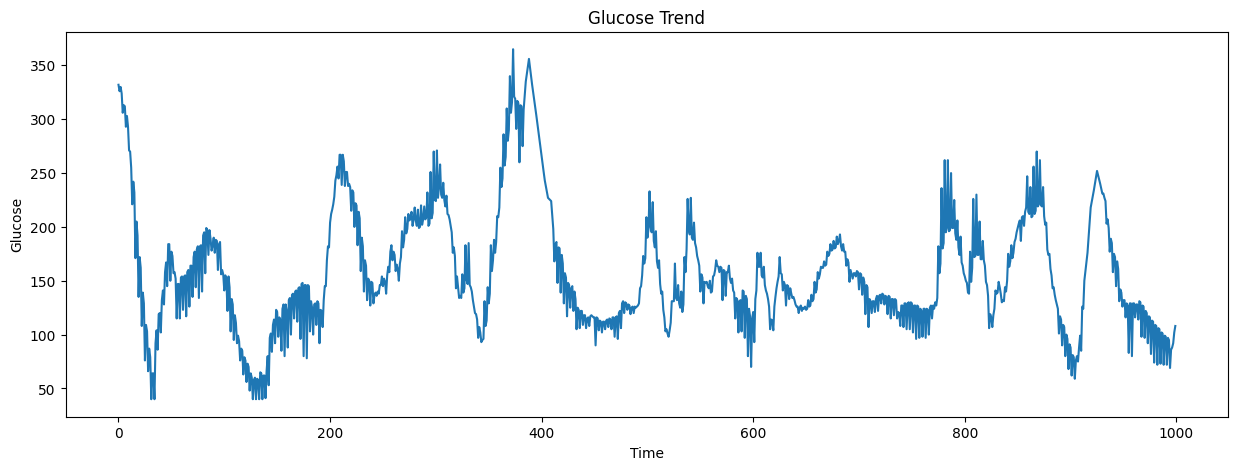

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(data['glucose'].values[:1000])

plt.title("Glucose Trend")
plt.xlabel("Time")
plt.ylabel("Glucose")

plt.show()

In [18]:
print(data['time'].head())

0    2018-06-13T18:40:00
1    2018-06-13T18:45:00
2    2018-06-13T18:50:00
3    2018-06-13T18:55:00
4    2018-06-13T19:00:00
Name: time, dtype: object


In [19]:
data['time'] = pd.to_datetime(data['time'])

In [20]:
print(data['time'].head())

0   2018-06-13 18:40:00
1   2018-06-13 18:45:00
2   2018-06-13 18:50:00
3   2018-06-13 18:55:00
4   2018-06-13 19:00:00
Name: time, dtype: datetime64[ns]


In [21]:
data['time'].unique()

<DatetimeArray>
['2018-06-13 18:40:00', '2018-06-13 18:45:00', '2018-06-13 18:50:00',
 '2018-06-13 18:55:00', '2018-06-13 19:00:00', '2018-06-13 19:05:00',
 '2018-06-13 19:10:00', '2018-06-13 19:15:00', '2018-06-13 19:20:00',
 '2018-06-13 19:25:00',
 ...
 '2022-05-18 11:30:00', '2022-05-18 11:35:00', '2022-05-18 11:40:00',
 '2022-05-18 11:45:00', '2022-05-18 11:50:00', '2022-05-18 11:55:00',
 '2022-05-18 12:00:00', '2022-05-18 12:05:00', '2022-05-18 12:10:00',
 '2022-05-18 12:15:00']
Length: 228802, dtype: datetime64[ns]

In [22]:
data['hour'] = data['time'].dt.hour

In [23]:
night_data = data[
    (data['hour'] >= 22) |
    (data['hour'] <= 6)
]

In [24]:
night_hypo = (night_data['glucose'] < 70).sum()

print("Nighttime Hypoglycemia Samples:", night_hypo)

Nighttime Hypoglycemia Samples: 8613


In [25]:
print("Total Night Samples:", len(night_data))

Total Night Samples: 115862


In [26]:
night_hypo_percent = (
    night_hypo / len(night_data)
) * 100

print("Nighttime Hypoglycemia Percentage:", night_hypo_percent)

Nighttime Hypoglycemia Percentage: 7.433843710621256


In [35]:
import numpy as np 

data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
data['is_nocturnal'] = ((data['hour'] >= 22) | (data['hour'] <= 6)).astype(int)



In [31]:
night_data = night_data.sort_values(['patient_id', 'time']).reset_index(drop=True)

HORIZON = 6
night_data['future_glucose'] = night_data.groupby('patient_id')['glucose'].shift(-HORIZON)

night_data['label'] = (night_data['future_glucose'] < 70).astype(int)

night_data = night_data.dropna(subset=['future_glucose'])

print("Label distribution:")
print(night_data['label'].value_counts())
print("Hypo %:", round(night_data['label'].mean() * 100, 2))

Label distribution:
label
0    106977
1      8585
Name: count, dtype: int64
Hypo %: 7.43


In [40]:
!pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------------- -------------------- 3.9/8.2 MB 21.5 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 21.9 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 20.4 MB/s eta 0:00:00
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   ---- ----------------------------------- 4.2/36.5 MB 20.9 MB/s eta 0:00:02
   --------- ------------------------------ 8.4/36.5 MB 20.0 MB/s eta 0:00:02
   ------------- -------------------------- 12.6/36.5 MB 20.2 MB/s eta 0:00:02
   ------------------ --------------------- 16.8/36.5 MB 19.9 MB/s eta 0:00:01
   ---------------------- ----------------- 20.4/36.5 MB 19.3 MB/s eta 0:00:01
   ------------------------ --------------- 22.0/36.5

In [42]:
patient_counts = night_data.groupby('patient_id').size().sort_values()
print(patient_counts)

patient_id
HUPA0006P      852
HUPA0021P      852
HUPA0020P     1068
HUPA0024P     1068
HUPA0010P     1087
HUPA0004P     1176
HUPA0002P     1189
HUPA0017P     1307
HUPA0015P     1392
HUPA0019P     1392
HUPA0009P     1392
HUPA0014P     1414
HUPA0016P     1414
HUPA0007P     1414
HUPA0003P     1414
HUPA0005P     1414
HUPA0011P     1414
HUPA0018P     1414
HUPA0023P     1476
HUPA0022P     1491
HUPA0025P     1500
HUPA0001P     1524
HUPA0028P     9708
HUPA0026P    15213
HUPA0027P    61977
dtype: int64


In [47]:
data['hypo_label'] = 0

for pid in data['patient_id'].unique():

    patient_idx = data[
        data['patient_id'] == pid
    ].index

    for pos, i in enumerate(patient_idx):

        future_idx = patient_idx[pos : pos + 7]

        future_glucose = data.loc[
            future_idx,
            'glucose'
        ]

        if (future_glucose < 70).any():
            data.loc[i, 'hypo_label'] = 1

In [48]:
print(data['hypo_label'].value_counts())

hypo_label
0    280249
1     29143
Name: count, dtype: int64


In [49]:
patient_stats = data.groupby(
    'patient_id'
)['hypo_label'].agg(
    ['count', 'sum']
)

print(patient_stats)

             count    sum
patient_id               
HUPA0001P     4096    156
HUPA0002P     3181    926
HUPA0003P     3770    386
HUPA0004P     3184    387
HUPA0005P     3858    225
HUPA0006P     2290    276
HUPA0007P     3857    465
HUPA0009P     3812      0
HUPA0010P     2976    336
HUPA0011P     3839    174
HUPA0014P     3829    221
HUPA0015P     3792    242
HUPA0016P     3835    765
HUPA0017P     3599    142
HUPA0018P     3895    852
HUPA0019P     3711    220
HUPA0020P     2862    162
HUPA0021P     2343    159
HUPA0022P     4023    753
HUPA0023P     3919    230
HUPA0024P     2902    298
HUPA0025P     4006    718
HUPA0026P    40605   4072
HUPA0027P   165306  15657
HUPA0028P    25902   1321


In [50]:
print(data['patient_id'].nunique())

25


In [51]:
import numpy as np

night_data['hour_sin'] = np.sin(2 * np.pi * night_data['hour'] / 24)
night_data['hour_cos'] = np.cos(2 * np.pi * night_data['hour'] / 24)
print(night_data[['hour', 'hour_sin', 'hour_cos']].head())

   hour  hour_sin  hour_cos
0    22      -0.5  0.866025
1    22      -0.5  0.866025
2    22      -0.5  0.866025
3    22      -0.5  0.866025
4    22      -0.5  0.866025


In [53]:
test_patients  = ['HUPA0025P', 'HUPA0009P', 'HUPA0006P', 'HUPA0021P']
val_patients   = ['HUPA0026P', 'HUPA0018P', 'HUPA0022P']
train_patients = [p for p in night_data['patient_id'].unique()
                  if p not in test_patients + val_patients]

train_data = night_data[night_data['patient_id'].isin(train_patients)].reset_index(drop=True)
val_data   = night_data[night_data['patient_id'].isin(val_patients)].reset_index(drop=True)
test_data  = night_data[night_data['patient_id'].isin(test_patients)].reset_index(drop=True)

print("Train:", train_data.shape)
print("Val:  ", val_data.shape)
print("Test: ", test_data.shape)
print("\nTrain hypo%:", round(train_data['label'].mean()*100, 2))
print("Val hypo%:  ", round(val_data['label'].mean()*100, 2))
print("Test hypo%: ", round(test_data['label'].mean()*100, 2))

Train: (92848, 14)
Val:   (18118, 14)
Test:  (4596, 14)

Train hypo%: 6.93
Val hypo%:   9.82
Test hypo%:  8.01


In [54]:
print(train_data['patient_id'].nunique())
print(val_data['patient_id'].nunique())
print(test_data['patient_id'].nunique())

18
3
4


In [55]:
train_data.to_csv("train_data.csv", index=False)
val_data.to_csv("val_data.csv", index=False)
test_data.to_csv("test_data.csv", index=False)

In [56]:
feature_cols = [
    'glucose',
    'calories',
    'heart_rate',
    'steps',
    'basal_rate',
    'bolus_volume_delivered',
    'carb_input',
    'hour_sin',
    'hour_cos'
]

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_data[feature_cols] = scaler.fit_transform(
    train_data[feature_cols]
)

val_data[feature_cols] = scaler.transform(
    val_data[feature_cols]
)

test_data[feature_cols] = scaler.transform(
    test_data[feature_cols]
)

In [58]:
print(train_data[feature_cols].describe())

            glucose      calories    heart_rate         steps    basal_rate  \
count  9.284800e+04  9.284800e+04  9.284800e+04  9.284800e+04  9.284800e+04   
mean   6.856866e-17  1.689728e-16  4.603896e-16  7.346642e-18  1.959105e-17   
std    1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00   
min   -1.768023e+00 -7.259433e-01 -2.093997e+00 -1.762171e-01 -1.147591e+00   
25%   -7.207654e-01 -1.839402e-01 -7.119375e-01 -1.762171e-01 -1.147591e+00   
50%   -1.645499e-01 -1.839402e-01 -2.884216e-01 -1.762171e-01  5.390609e-01   
75%    5.102217e-01 -1.213400e-01  4.322305e-01 -1.762171e-01  7.582303e-01   
max    5.654645e+00  1.486613e+01  7.011329e+00  1.628267e+01  3.026157e+00   

       bolus_volume_delivered    carb_input      hour_sin      hour_cos  
count            9.284800e+04  9.284800e+04  9.284800e+04  9.284800e+04  
mean            -2.448881e-18  1.224440e-17  1.147913e-16 -1.931555e-16  
std              1.000005e+00  1.000005e+00  1.000005e+00  1.00000